device: cpu
epoch 1: train loss 1.0376 test loss 0.4379 train acc 0.8734 test acc 0.8816
epoch 1: train 1.0376 test 0.4379
epoch 2: train loss 0.3818 test loss 0.3187 train acc 0.9048 test acc 0.9107
epoch 2: train 0.3818 test 0.3187
epoch 3: train loss 0.3082 test loss 0.2788 train acc 0.9179 test acc 0.9201
epoch 3: train 0.3082 test 0.2788
epoch 4: train loss 0.2733 test loss 0.2542 train acc 0.9262 test acc 0.9261
epoch 4: train 0.2733 test 0.2542
epoch 5: train loss 0.2478 test loss 0.2367 train acc 0.9318 test acc 0.9315
epoch 5: train 0.2478 test 0.2367
epoch 6: train loss 0.2259 test loss 0.2142 train acc 0.9403 test acc 0.9379
epoch 6: train 0.2259 test 0.2142
epoch 7: train loss 0.2069 test loss 0.1976 train acc 0.9444 test acc 0.9430
epoch 7: train 0.2069 test 0.1976
epoch 8: train loss 0.1902 test loss 0.1839 train acc 0.9494 test acc 0.9473
epoch 8: train 0.1902 test 0.1839
epoch 9: train loss 0.1764 test loss 0.1721 train acc 0.9529 test acc 0.9499
epoch 9: train 0.1764 t

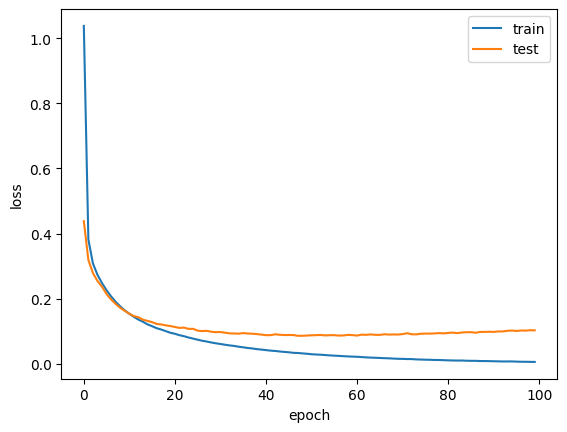

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print(torch.cuda.get_device_name(0))

# Load raw MNIST once
train_raw = datasets.MNIST("./data", train=True, download=True)
test_raw = datasets.MNIST("./data", train=False, download=True)

# Convert once, normalise once, move to GPU once
X_train = train_raw.data.float().div(255.0)
X_train = (X_train - 0.1307) / 0.3081
X_train = X_train.view(-1, 28 * 28).to(device)

y_train = (train_raw.targets % 2).to(device)

X_test = test_raw.data.float().div(255.0)
X_test = (X_test - 0.1307) / 0.3081
X_test = X_test.view(-1, 28 * 28).to(device)

y_test = (test_raw.targets % 2).to(device)

model = nn.Sequential(
    nn.Linear(28 * 28, 64),
    nn.ReLU(),
    nn.Linear(64, 2),
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)              # shape: [N, 10]
        preds = logits.argmax(dim=1)   # predicted digit 0-9
        acc = (preds == y).float().mean()
    return acc.item()

epochs = 100
batch_size = 2048

train_losses, test_losses = [], []

for epoch in range(epochs):
    model.train()

    perm = torch.randperm(X_train.size(0), device=device)
    total_loss = 0.0

    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i + batch_size]
        x = X_train[idx]
        y = y_train[idx]

        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()

        total_loss += loss.detach() * x.size(0)

    train_loss = (total_loss / X_train.size(0)).item()
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        test_loss = loss_fn(model(X_test), y_test).item()
    test_losses.append(test_loss)

    train_acc = accuracy(model, X_train, y_train)
    test_acc = accuracy(model, X_test, y_test)

    print(
        f"epoch {epoch+1}: "
        f"train loss {train_loss:.4f} "
        f"test loss {test_loss:.4f} "
        f"train acc {train_acc:.4f} "
        f"test acc {test_acc:.4f}"
    )

    print(f"epoch {epoch+1}: train {train_loss:.4f} test {test_loss:.4f}")

# plt.plot(train_losses, label="train")
# plt.plot(test_losses, label="test")
# plt.xlabel("epoch")
# plt.ylabel("loss")
# plt.legend()
# plt.show()